In [6]:
# ============================================================
# NOTEBOOK 05 — Integrated Visualisation & Results
# Final summary figures for the report and presentation
# ============================================================

# ── CELL 1: Path Setup & Imports ─────────────────────────────────────────────
import os, sys
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

# Resolve project root
_cwd = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, '..')) \
               if not os.path.exists(os.path.join(_cwd, 'Data')) else _cwd

DATA_DIR   = os.path.join(PROJECT_ROOT, 'Data')
OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'Outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {'✅' if os.path.exists(DATA_DIR) else '❌'}")
print(f"OUTPUT_DIR   : ✅")







PROJECT_ROOT : C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike
DATA_DIR     : ✅
OUTPUT_DIR   : ✅


In [7]:
# ── CELL 2: Load All Processed Data ──────────────────────────────────────────
comments_df = pd.read_csv(os.path.join(DATA_DIR, 'comments_with_sentiment_topics.csv'))
videos_df   = pd.read_csv(os.path.join(DATA_DIR, 'videos_processed.csv'))
metrics_df  = pd.read_csv(os.path.join(DATA_DIR, 'network_metrics.csv'))

# Load channel indegree if available
channel_indegree_path = os.path.join(DATA_DIR, 'channel_indegree.csv')
indegree_df = pd.read_csv(channel_indegree_path) \
              if os.path.exists(channel_indegree_path) else None

print(f"Comments : {len(comments_df)} rows | Columns: {comments_df.columns.tolist()}")
print(f"Videos   : {len(videos_df)} rows")
print(f"Metrics  : {len(metrics_df)} rows")
if indegree_df is not None:
    print(f"Channels : {len(indegree_df)} rows")


Comments : 11398 rows | Columns: ['comment_id', 'video_id', 'author_id', 'author_name', 'text', 'like_count', 'reply_count', 'published_at', 'updated_at', 'year_month', 'day_of_week', 'hour', 'is_english', 'text_clean', 'compound', 'label', 'pos', 'neg', 'neu', 'topic_id', 'prob', 'topic_label']
Videos   : 212 rows
Metrics  : 85 rows
Channels : 10624 rows


In [8]:
# ── CELL 3: Rebuild LDA model for topic labels ────────────────────────────────
# (needed for plot labels — model is not saved to disk)
from Utils.nlp_utils import (
    build_lda_model,
    get_topic_labels,
    plot_topic_sentiment_heatmap,
    plot_wordcloud_per_topic,
)

# Detect text column
TEXT_COL = next((c for c in ['text_clean', 'text', 'textDisplay', 'text_display']
                 if c in comments_df.columns), None)
if TEXT_COL is None:
    raise ValueError(f"No text column found. Available: {comments_df.columns.tolist()}")
print(f"Using text column: '{TEXT_COL}'")

NUM_TOPICS = int(comments_df['topic_id'].max() + 1) \
             if 'topic_id' in comments_df.columns else 6
print(f"Rebuilding LDA with {NUM_TOPICS} topics for label extraction...")

lda_model, dtm, vectorizer, _ = build_lda_model(
    comments_df[TEXT_COL].dropna().tolist(),
    num_topics=NUM_TOPICS,
    max_iter=30,
    random_state=42,
)
topic_labels = get_topic_labels(lda_model, vectorizer, num_words=10)
print("✅ Topic labels ready:")
for tid, words in topic_labels.items():
    print(f"   Topic {tid}: {', '.join(words[:5])}")


11:59:20 [INFO] Cleaning 11180 documents...


Using text column: 'text_clean'
Rebuilding LDA with 6 topics for label extraction...


11:59:22 [INFO] Vocabulary size: 2000 terms
11:59:22 [INFO] Training LDA: 6 topics, 30 iterations...
11:59:40 [INFO] Training complete. Perplexity: 1146.39 (lower = better fit)


✅ Topic labels ready:
   Topic 0: hai, pakistan, india, bhi, nahi
   Topic 1: australia, company, country, day, supply
   Topic 2: trump, war, iran, american, world
   Topic 3: car, year, battery, drive, mile
   Topic 4: government, tax, nuclear, week, dollar
   Topic 5: trump, biden, diesel, vote, thank


In [9]:
# ── CELL 4: Engagement score for videos (if not already present) ──────────────
if 'engagement_score' not in videos_df.columns:
    # Compute from available columns
    view_col  = next((c for c in ['view_count','viewCount','views'] if c in videos_df.columns), None)
    like_col  = next((c for c in ['like_count','likeCount','likes'] if c in videos_df.columns), None)
    cmt_col   = next((c for c in ['comment_count','commentCount','comments'] if c in videos_df.columns), None)

    for col in [view_col, like_col, cmt_col]:
        if col:
            videos_df[col] = pd.to_numeric(videos_df[col], errors='coerce').fillna(0)

    if view_col and like_col and cmt_col:
        videos_df['engagement_score'] = (
            videos_df[like_col] + videos_df[cmt_col] * 2
        ) / (videos_df[view_col] + 1) * 1000
        print(f"✅ engagement_score computed from {like_col}, {cmt_col}, {view_col}")
    elif cmt_col:
        videos_df['engagement_score'] = videos_df[cmt_col]
        print(f"✅ engagement_score = {cmt_col} (view count unavailable)")
    else:
        videos_df['engagement_score'] = 1
        print("⚠️  No numeric engagement columns found — using placeholder")





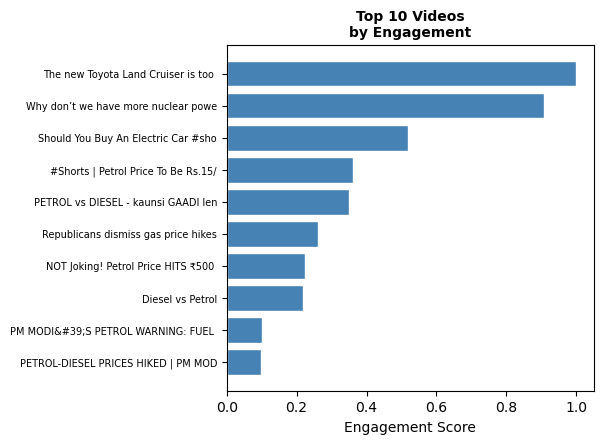

In [10]:
# ── CELL 5: FIGURE 1 — Summary Dashboard (2×3 grid) ─────────────────────────
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── Panel 1: Top 10 Videos by Engagement ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
title_col = next((c for c in ['title', 'video_title', 'name']
                  if c in videos_df.columns), 'video_id')
top10 = videos_df.nlargest(10, 'engagement_score')
ax1.barh(top10[title_col].str[:35], top10['engagement_score'],
         color='steelblue', edgecolor='white')
ax1.set_title("Top 10 Videos\nby Engagement", fontweight='bold', fontsize=10)
ax1.set_xlabel("Engagement Score")
ax1.invert_yaxis()
ax1.tick_params(axis='y', labelsize=7)


In [11]:
# ── Panel 2: Sentiment Pie ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
s_counts = comments_df['label'].value_counts()
colors_s = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
pie_colors = [colors_s.get(l, 'steelblue') for l in s_counts.index]
wedges, texts, autotexts = ax2.pie(
    s_counts, labels=s_counts.index, colors=pie_colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_fontsize(9)
ax2.set_title("Comment Sentiment\nDistribution", fontweight='bold', fontsize=10)

# ── Panel 3: PageRank Distribution ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(metrics_df['pagerank'], bins=40, color='coral', edgecolor='white')
ax3.set_title("PageRank Distribution\n(Co-Comment Network)", fontweight='bold', fontsize=10)
ax3.set_xlabel("PageRank Score")
ax3.set_ylabel("Number of Users")
ax3.annotate("Long tail: few\nhighly influential users",
             xy=(metrics_df['pagerank'].quantile(0.99), 5),
             fontsize=7, color='red',
             arrowprops=dict(arrowstyle='->', color='red'),
             xytext=(metrics_df['pagerank'].max() * 0.5, 30))


Text(0.026207, 30, 'Long tail: few\nhighly influential users')

In [12]:
# ── Panel 4: Top 10 Influential Commenters ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
top_users = metrics_df.head(10)
node_labels = top_users['node'].str[:18]
ax4.barh(node_labels, top_users['pagerank'], color='orchid', edgecolor='white')
ax4.set_title("Top 10 Most Influential\nCommenters (PageRank)", fontweight='bold', fontsize=10)
ax4.set_xlabel("PageRank Score")
ax4.invert_yaxis()
ax4.tick_params(axis='y', labelsize=7)

# ── Panel 5: Topic Distribution ──────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
if 'topic_id' in comments_df.columns:
    topic_dist = comments_df[comments_df['topic_id'] >= 0]['topic_id'].value_counts().sort_index()
    t_labels = [f"T{i}:\n{', '.join(topic_labels.get(i,[])[:2])}"
                for i in topic_dist.index]
    ax5.bar(t_labels, topic_dist.values, color='teal', edgecolor='white')
    ax5.set_title("Topic Distribution\nAcross Comments", fontweight='bold', fontsize=10)
    ax5.set_xlabel("Topic")
    ax5.set_ylabel("Comments")
    ax5.tick_params(axis='x', labelsize=7)
else:
    ax5.text(0.5, 0.5, "topic_id not found\nRun Notebook 04 first",
             ha='center', va='center', transform=ax5.transAxes, color='red')


In [13]:
# ── Panel 6: Top Channels by Incoming Engagement ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
if indegree_df is not None:
    top_ch = indegree_df.head(10)
    ax6.barh(top_ch['channel_id'].str[:20], top_ch['in_degree_weighted'],
             color='#f39c12', edgecolor='white')
    ax6.set_title("Top 10 Channels\nby Incoming Engagement", fontweight='bold', fontsize=10)
    ax6.set_xlabel("Weighted In-Degree")
    ax6.invert_yaxis()
    ax6.tick_params(axis='y', labelsize=7)
else:
    ax6.text(0.5, 0.5, "channel_indegree.csv\nnot found",
             ha='center', va='center', transform=ax6.transAxes, color='grey')

plt.suptitle(
    "Fuel Price Hike — YouTube Social Media & Network Analysis Summary",
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig(os.path.join(OUTPUT_DIR, '14_summary_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: 14_summary_dashboard.png")



<Figure size 640x480 with 0 Axes>

✅ Saved: 14_summary_dashboard.png


11:59:40 [INFO] Saved: C:\Users\RENGAN\Desktop\Social Media Analytics\Fuel Price hike\Outputs\15_topic_sentiment_heatmap.png


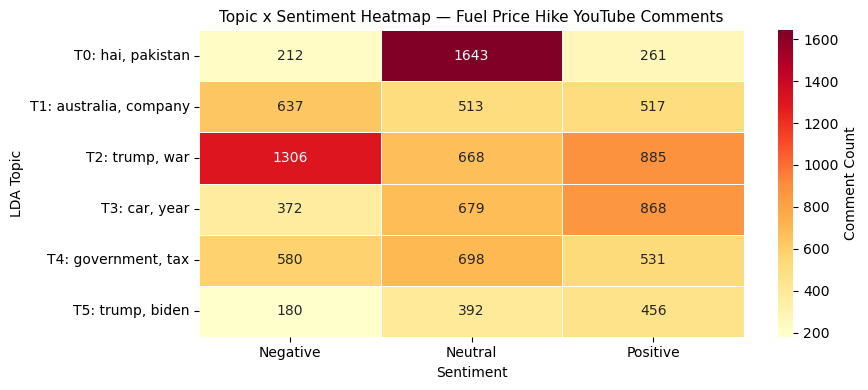

In [14]:
# ── CELL 6: FIGURE 2 — Topic × Sentiment Heatmap ────────────────────────────
plot_topic_sentiment_heatmap(
    comments_df,
    topic_col='topic_id',
    label_col='label',
    topic_labels=topic_labels,
    save_path=os.path.join(OUTPUT_DIR, '15_topic_sentiment_heatmap.png')
)



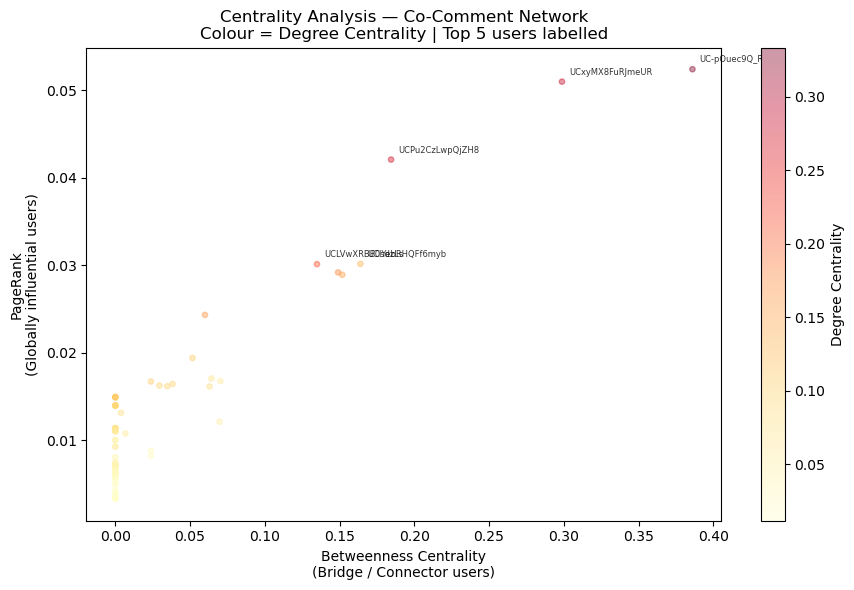

✅ Saved: 16_centrality_scatter.png


In [15]:
# ── CELL 7: FIGURE 3 — Betweenness vs PageRank ───────────────────────────────
# Identifies two types of influential users:
#   High PageRank        = globally influential (many connections)
#   High Betweenness     = bridge users (connect different communities)

plt.figure(figsize=(9, 6))
sc = plt.scatter(
    metrics_df['betweenness_c'],
    metrics_df['pagerank'],
    alpha=0.4, s=15, c=metrics_df['degree_c'],
    cmap='YlOrRd'
)
plt.colorbar(sc, label='Degree Centrality')

# Annotate top 5 users
for _, row in metrics_df.head(5).iterrows():
    plt.annotate(
        str(row['node'])[:15],
        (row['betweenness_c'], row['pagerank']),
        fontsize=6, alpha=0.8,
        xytext=(5, 5), textcoords='offset points'
    )

plt.xlabel("Betweenness Centrality\n(Bridge / Connector users)")
plt.ylabel("PageRank\n(Globally influential users)")
plt.title("Centrality Analysis — Co-Comment Network\n"
          "Colour = Degree Centrality | Top 5 users labelled")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '16_centrality_scatter.png'), dpi=150)
plt.show()
print("✅ Saved: 16_centrality_scatter.png")



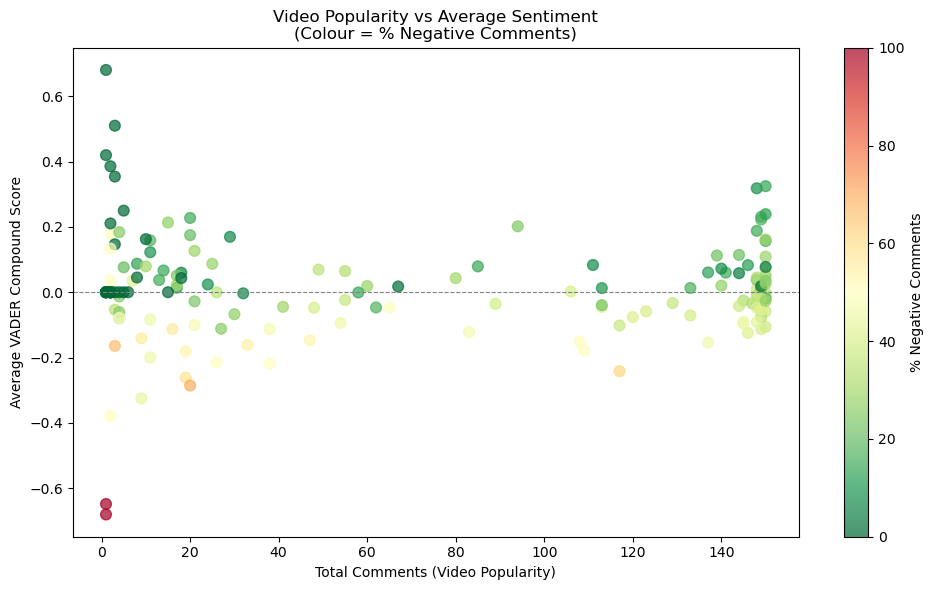

✅ Saved: 17_video_sentiment_scatter.png


In [16]:
# ── CELL 8: FIGURE 4 — Sentiment vs Comment Volume per Video ─────────────────
if 'video_id' in comments_df.columns:
    video_stats = (comments_df.groupby('video_id')
                   .agg(
                       total_comments=('label', 'count'),
                       avg_compound=('compound', 'mean'),
                       pct_negative=('label', lambda x: (x == 'Negative').mean() * 100),
                   )
                   .reset_index())

    # Merge with video titles
    if 'title' in videos_df.columns:
        video_stats = video_stats.merge(
            videos_df[['video_id', 'title']].drop_duplicates(),
            on='video_id', how='left'
        )

    plt.figure(figsize=(10, 6))
    sc2 = plt.scatter(
        video_stats['total_comments'],
        video_stats['avg_compound'],
        c=video_stats['pct_negative'],
        cmap='RdYlGn_r', alpha=0.7, s=60
    )
    plt.colorbar(sc2, label='% Negative Comments')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.xlabel("Total Comments (Video Popularity)")
    plt.ylabel("Average VADER Compound Score")
    plt.title("Video Popularity vs Average Sentiment\n"
              "(Colour = % Negative Comments)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '17_video_sentiment_scatter.png'), dpi=150)
    plt.show()
    print("✅ Saved: 17_video_sentiment_scatter.png")


In [17]:

# ── CELL 9: FIGURE 5 — Community Size Distribution ───────────────────────────
if 'community' in metrics_df.columns:
    community_sizes = metrics_df['community'].value_counts().reset_index()
    community_sizes.columns = ['community', 'size']

    plt.figure(figsize=(10, 4))
    plt.bar(range(len(community_sizes)), community_sizes['size'],
            color='steelblue', edgecolor='white')
    plt.title("Community Size Distribution — Louvain Communities")
    plt.xlabel("Community ID (ranked by size)")
    plt.ylabel("Number of Users")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '18_community_sizes.png'), dpi=150)
    plt.show()
    print("✅ Saved: 18_community_sizes.png")
else:
    print("⚠️  No 'community' column in metrics_df — skipping community size plot.")



⚠️  No 'community' column in metrics_df — skipping community size plot.


In [18]:
# ── CELL 10: FIGURE 6 — Sentiment per Community ──────────────────────────────
if 'community' in metrics_df.columns:
    # Merge community labels into comments via author_id
    comm_map = metrics_df[['node', 'community']].rename(columns={'node': 'author_id'})
    comm_sent = comments_df.merge(comm_map, on='author_id', how='inner')

    # Top 8 communities by comment volume
    top_communities = (comm_sent['community'].value_counts()
                       .head(8).index.tolist())
    comm_sent_top = comm_sent[comm_sent['community'].isin(top_communities)]

    pivot = (comm_sent_top.groupby(['community', 'label'])
             .size().unstack(fill_value=0))

    # Normalise to percentage
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    pivot_pct[['Positive', 'Neutral', 'Negative']].plot(
        kind='bar', stacked=True, figsize=(12, 5),
        color=['#2ecc71', '#95a5a6', '#e74c3c'],
        edgecolor='white'
    )
    plt.title("Sentiment Distribution per Community\n(Top 8 communities by comment volume)")
    plt.xlabel("Community ID")
    plt.ylabel("Percentage of Comments (%)")
    plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, '19_community_sentiment.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 19_community_sentiment.png")
else:
    print("⚠️  No 'community' column in metrics_df — skipping community sentiment plot.")


⚠️  No 'community' column in metrics_df — skipping community sentiment plot.


In [19]:
# ── CELL 11: KEY FINDINGS SUMMARY (for Report Section) ───────────────────────
print("\n" + "="*60)
print("KEY FINDINGS — FUEL PRICE HIKE YOUTUBE ANALYSIS")
print("="*60)

total = len(comments_df)
print(f"\n📊 Dataset")
print(f"   Videos analysed    : {len(videos_df)}")
print(f"   Comments analysed  : {total:,}")
print(f"   Unique commenters  : {comments_df['author_id'].nunique():,}")

print(f"\n💬 Sentiment")
for label in ['Positive', 'Neutral', 'Negative']:
    count = (comments_df['label'] == label).sum()
    print(f"   {label:10s}: {count:,} ({count/total*100:.1f}%)")
print(f"   Mean compound score: {comments_df['compound'].mean():.4f}")

print(f"\n🌐 Network (Co-Comment Graph)")
print(f"   Nodes (users)      : {metrics_df['node'].nunique():,}")
print(f"   Top user (PageRank): {metrics_df.iloc[0]['node']}")
print(f"   Top PageRank score : {metrics_df.iloc[0]['pagerank']:.6f}")
if 'betweenness_c' in metrics_df.columns:
    top_bridge = metrics_df.sort_values('betweenness_c', ascending=False).iloc[0]
    print(f"   Top bridge user    : {top_bridge['node']}")

print(f"\n🔍 Topics (LDA, k={NUM_TOPICS})")
for tid, words in topic_labels.items():
    count = (comments_df['topic_id'] == tid).sum()
    print(f"   Topic {tid} [{', '.join(words[:3])}]: "
          f"{count:,} comments ({count/total*100:.1f}%)")

if indegree_df is not None:
    print(f"\n📺 Channel Network")
    print(f"   Most engaged channel: {indegree_df.iloc[0]['channel_id']}")
    print(f"   Incoming interactions: {int(indegree_df.iloc[0]['in_degree_weighted']):,}")

print("\n" + "="*60)
print("✅ All outputs saved to:", OUTPUT_DIR)
print("="*60)


KEY FINDINGS — FUEL PRICE HIKE YOUTUBE ANALYSIS

📊 Dataset
   Videos analysed    : 212
   Comments analysed  : 11,398
   Unique commenters  : 10,530

💬 Sentiment
   Positive  : 3,518 (30.9%)
   Neutral   : 4,593 (40.3%)
   Negative  : 3,287 (28.8%)
   Mean compound score: 0.0095

🌐 Network (Co-Comment Graph)
   Nodes (users)      : 85
   Top user (PageRank): UC-pOuec9Q_RiRlk7Tl3ek4Q
   Top PageRank score : 0.052414
   Top bridge user    : UC-pOuec9Q_RiRlk7Tl3ek4Q

🔍 Topics (LDA, k=6)
   Topic 0 [hai, pakistan, india]: 2,116 comments (18.6%)
   Topic 1 [australia, company, country]: 1,667 comments (14.6%)
   Topic 2 [trump, war, iran]: 2,859 comments (25.1%)
   Topic 3 [car, year, battery]: 1,919 comments (16.8%)
   Topic 4 [government, tax, nuclear]: 1,809 comments (15.9%)
   Topic 5 [trump, biden, diesel]: 1,028 comments (9.0%)

📺 Channel Network
   Most engaged channel: UCaXkIU1QidjPwiAYu6GcHjg
   Incoming interactions: 1,318

✅ All outputs saved to: C:\Users\RENGAN\Desktop\Social M